#### Problem Statement :
#### A company is looking to devlop a text classifiction  model to categorize customer reviews into positive or negative sentiments. They want to use naive Bayes classification to automatically analyze and classify the reviews thet receive , aiming to understand customer that can accurately predict whether a customer review expresses a positive or negative sentiment.

In [ ]:
# Step 1 : Importing required libraries for data handling, visualization and ML 
import pandas as pd 
import string 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix


In [ ]:
# Step : 2 Loading dataset to understand the structure and content
df = pd.read_csv("customer_reviews.csv")

# Display the first 5 rows 
print("First 5 Rows : ")
print(df.head())

First 5 Rows : 
                                        review sentiment
0  This product is amazing and works perfectly  positive
1           I am very happy with this purchase  positive
2          Excellent quality and fast delivery  positive
3                      Totally worth the money  positive
4                             I love this item  positive


In [19]:
# Step : 3 Understanding the Data 

# Check dataset shape 
print("\nDataset Shape :",df.shape)

# Check column names 
print("\nColumn Names:")
print(df.columns)

# Check Missing Values 
print("\nMissing Values : ")
print(df.isnull().sum())

# Check duplicate rows 
print("\nDuplicate Rows : ",df.duplicated().sum())

# Check sentiment distribution 
print("\nSentiment Distribution : ")
print(df["sentiment"].value_counts)


Dataset Shape : (110, 2)

Column Names:
Index(['review', 'sentiment'], dtype='object')

Missing Values : 
review       0
sentiment    0
dtype: int64

Duplicate Rows :  0

Sentiment Distribution : 
<bound method IndexOpsMixin.value_counts of 0      positive
1      positive
2      positive
3      positive
4      positive
         ...   
105    negative
106    negative
107    negative
108    negative
109    negative
Name: sentiment, Length: 110, dtype: object>


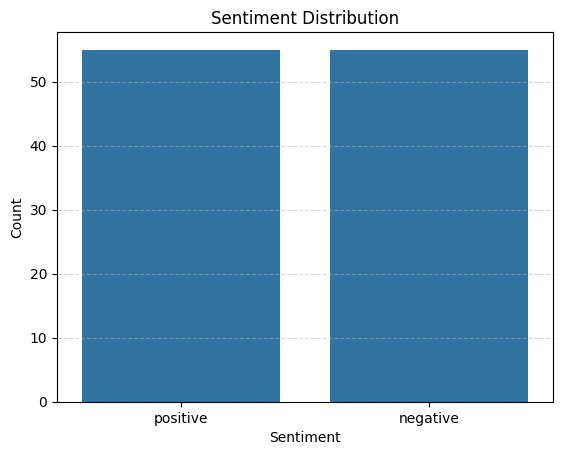

In [ ]:
# Visual 1 :  Visualizing sentiment distribution to check class balance

# Plot the count of positive and negative reviews 
sns.countplot(x="sentiment" , data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.grid(axis="y", linestyle = "--" , alpha = 0.5)
plt.savefig("images/Sentiment Distribution.png")
plt.show()

In [ ]:
# Step 4 : Cleaning text data to remove noise and standardize format 

# Define a funcion to clean review text 
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation marks 
    text = text.translate(str.maketrans("","",string.punctuation))
    
    return text

# Apply text cleaning on the review column 
df["review"] = df["review"].astype(str).apply(clean_text)

# Display cleaned review samples 
print("\nCleaned Reviews : ")
print(df["review"].head())


Cleaned Reviews : 
0    this product is amazing and works perfectly
1             i am very happy with this purchase
2            excellent quality and fast delivery
3                        totally worth the money
4                               i love this item
Name: review, dtype: object


In [ ]:
# Step 5 : Converting text into numerical features using CountVectorizer

# convert review text into word  count vectors 
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

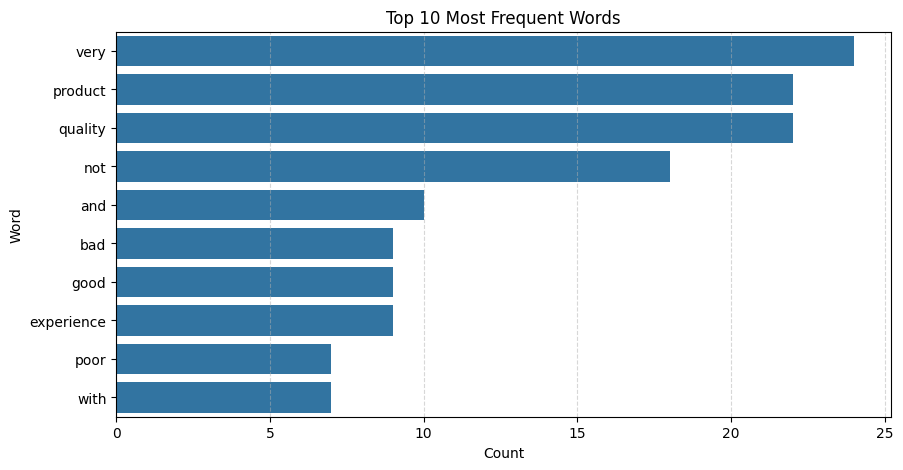

In [30]:
# Visual 2 : Top 10 most frequent words 

# Get total word counts from the vectorized data 
word_counts = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()

# Create a dataframe for word frequencies 
word_freq_df = pd.DataFrame({
    "Word": words,
    "Count": word_counts
})

# Select top 10 most frequent words 
top_words = word_freq_df.sort_values(by="Count" , ascending=False).head(10)

# Plot top frequent words 
plt.figure(figsize=(10,5))
sns.barplot(x="Count" , y="Word" , data=top_words)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.grid(axis="x" , linestyle= "--" , alpha = 0.5)
plt.savefig("images/Top 10 Most Frequent Words.png")
plt.show()

In [ ]:
# Step 6 : Splitting data into training and testing sets for model evaluation 

# Split dataset for training and testing 
X_train , X_test , y_train , y_test = train_test_split(
    X , y ,
    test_size= 0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :",X_train.shape)
print("Test Shape : " , X_test.shape)


Train Shape : (88, 115)
Test Shape :  (22, 115)


In [ ]:
# Step 7 : Initializing and training the Naive Bayes model

# Create the Multinomial Naive Bayes model 
model = MultinomialNB()

# Train the model 
model.fit(X_train , y_train)

print("\nModel trained successfully.")


Model trained successfully.


In [26]:
# Step 8 : Make Predictions 

# Predict sentiment on test data 
y_pred = model.predict(X_test)

In [ ]:
# Step 9 : Evaluating model performance using accuracy and classification metrics

# Calculate accuracy 
accuracy = accuracy_score(y_test , y_pred)
print("\nAccuracy Score : " , accuracy)

# Print confusion matrix 
print("\nConfusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

# Print classification report 
print("\nClassification Report : ")
print(classification_report(y_test , y_pred))


Accuracy Score :  0.9090909090909091

Confusion Matrix : 
[[10  1]
 [ 1 10]]

Classification Report : 
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91        11
    positive       0.91      0.91      0.91        11

    accuracy                           0.91        22
   macro avg       0.91      0.91      0.91        22
weighted avg       0.91      0.91      0.91        22



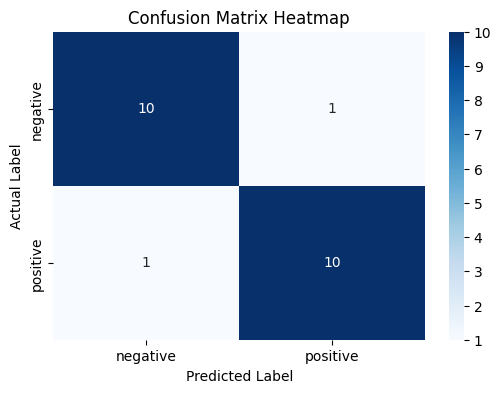

In [ ]:
# Visual 3 : Visualizing confusion matrix for better interpretation of results

# Create cunfusion matrix 
cm = confusion_matrix(y_test , y_pred)

# Plot confusion matrix as a heatmap 
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig("images/Confusion Matrix Heatmap.png")
plt.show()

In [ ]:
# Step 10 : Testing model with a custom review input
# Enter a custom review 
custom_review = ["this product is very good and useful"]

# Transform the custom review using the same vectorizer 
custom_vector = vectorizer.transform(custom_review)

# Predict sentiment 
prediction = model.predict(custom_vector)

# Display the prediction result 
print("\nCustom Review Prediction : " , prediction[0])


Custom Review Prediction :  positive


### step 11: Business Impact

This model helps companies:
- automatically analyze thousands of customer reviews  
- identify customer satisfaction trends  
- reduce manual effort in feedback analysis  
- improve products based on customer sentiment  

This leads to faster decision-making and better customer experience.

### step : 12 Future Improvements

- Use TF-IDF instead of CountVectorizer  
- Remove stopwords  
- Apply stemming/lemmatization  
- Try advanced models like Logistic Regression or SVM  
- Extend to multi-class sentiment (positive, neutral, negative)  
- Deploy using Streamlit  

## Conclusion: 

* This project demonstrates how Naive Bayes can be effectively used for sentiment analysis.  
* It shows a complete NLP pipeline from text preprocessing to model evaluation and prediction.